In [18]:
import sys

sys.path.append("..")

import torch
import matplotlib.pyplot as plt
import numpy as np

from src.paths import Paths
from src.utils import (
    get_device,
    tensor_to_img,
    plot_image,
    initialize_resnet18,
    load_model_weights,
)
from src.data_manager import DataManager
from src.perturbations import Perturbations
from src import config
from src.explainers import IGExplainer, OcclusionExplainer
from src.xai_experiment import XAIExperiment

## Konfiguracja ogólna

In [3]:
dataset_name = "mnist"
sigma = 0.8


device = get_device()
empty_model = initialize_resnet18(pretrained=False)

paths = Paths()

model = load_model_weights(empty_model, paths.MNIST_MODEL, device)

data_manager = DataManager(paths.DATA_DIR)

test_data = data_manager.get_test_dataset(dataset_name=dataset_name, download=False)
class_names = data_manager.get_class_names(dataset_name=dataset_name)

perturbations = Perturbations(model=model, device=device)

clean_examples = {}
for image, label in test_data:
    if label in clean_examples:
        continue

    tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = output.argmax(dim=1).item()

    if pred == label:
        clean_examples[label] = image

    if len(clean_examples) == len(class_names):
        break


## Konfiguracja IG

In [15]:
ig_explainer = IGExplainer(model=model, device=device, config=config.IGConfig())
ig_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=ig_explainer,
    perturbations=perturbations,
)

ig_classes = ig_experiment.selected_classes

all_ig_attrs = []
for class_id in ig_classes:
    clean_tensor = ig_experiment.get_clean_tensor(class_id)
    noised_tensor = ig_experiment.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=sigma,
    )

    clean_attr = ig_experiment.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["abs"]

    noised_attr = ig_experiment.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["abs"]

    all_ig_attrs.append(clean_attr)
    all_ig_attrs.append(noised_attr)

ig_vmin = 0
ig_vmax = np.percentile([attr.flatten() for attr in all_ig_attrs], 99)


## Czyste obrazy

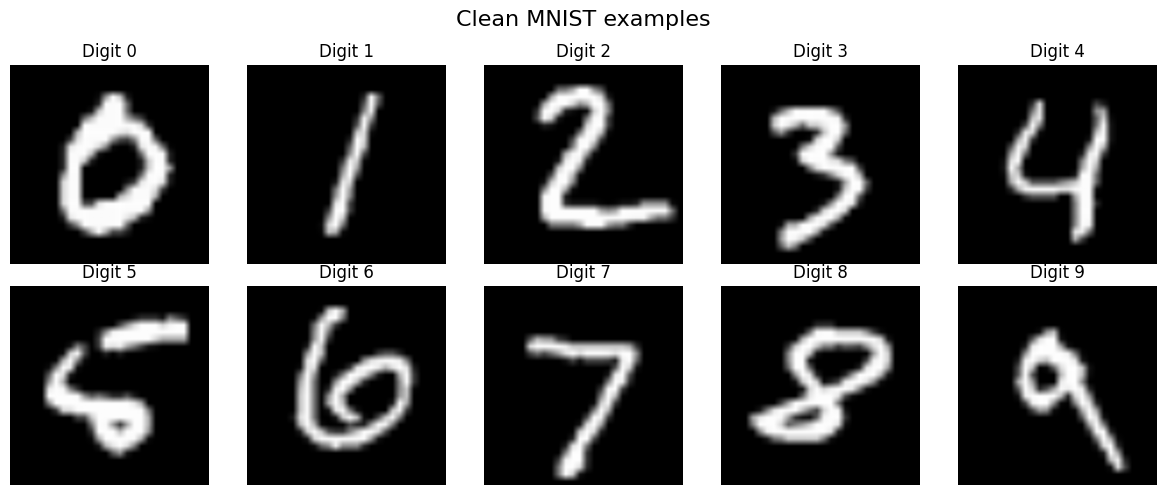

In [5]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5),
)

fig.suptitle("Clean MNIST examples", fontsize=16)

for idx, class_id in enumerate(ig_classes):
    row, col = divmod(idx, 5)

    clean_tensor = ig_experiment.get_clean_tensor(class_id, to_device=False)

    plot_image(
        axes[row, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {ig_experiment.class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG dla niezaszumionych danych

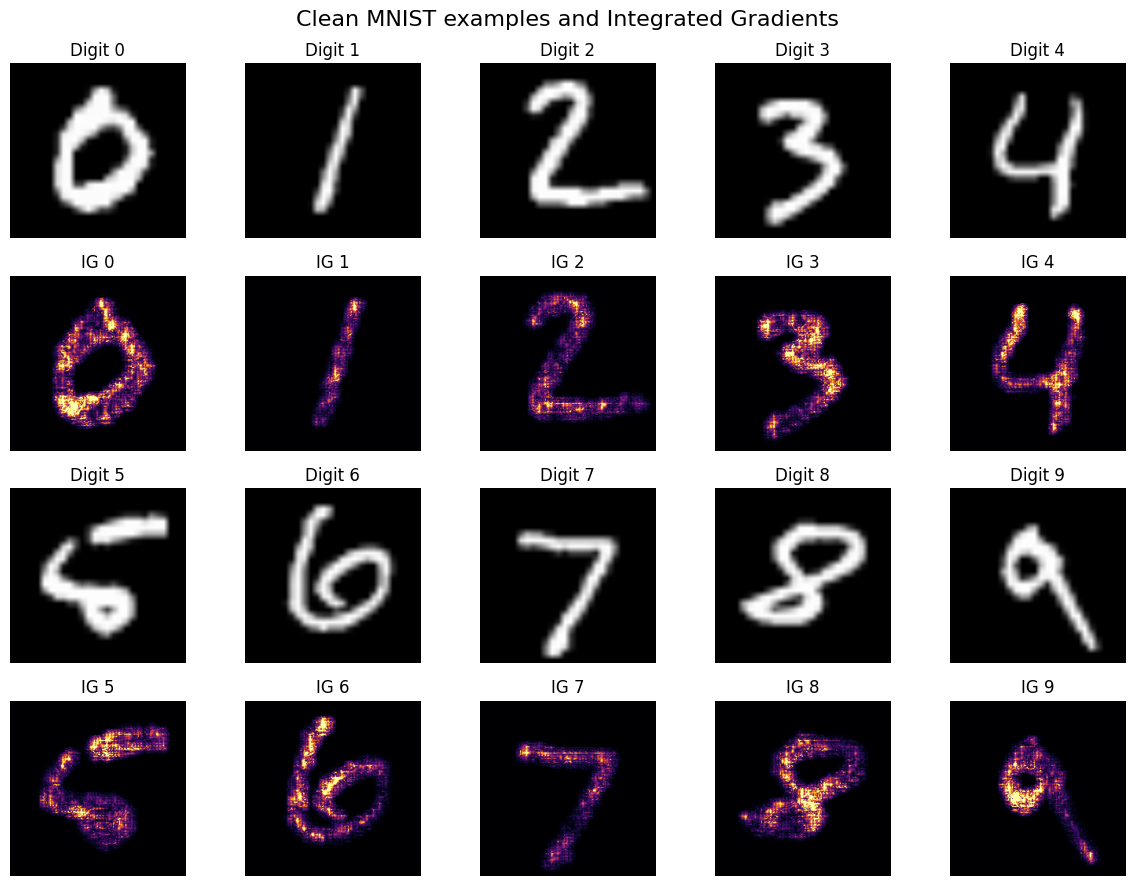

In [6]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "Clean MNIST examples and Integrated Gradients",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment.get_clean_tensor(class_id)
    clean_img = tensor_to_img(clean_tensor)

    attr_ig = ig_experiment.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_img,
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_ig,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Szum Gaussa - prezentacja

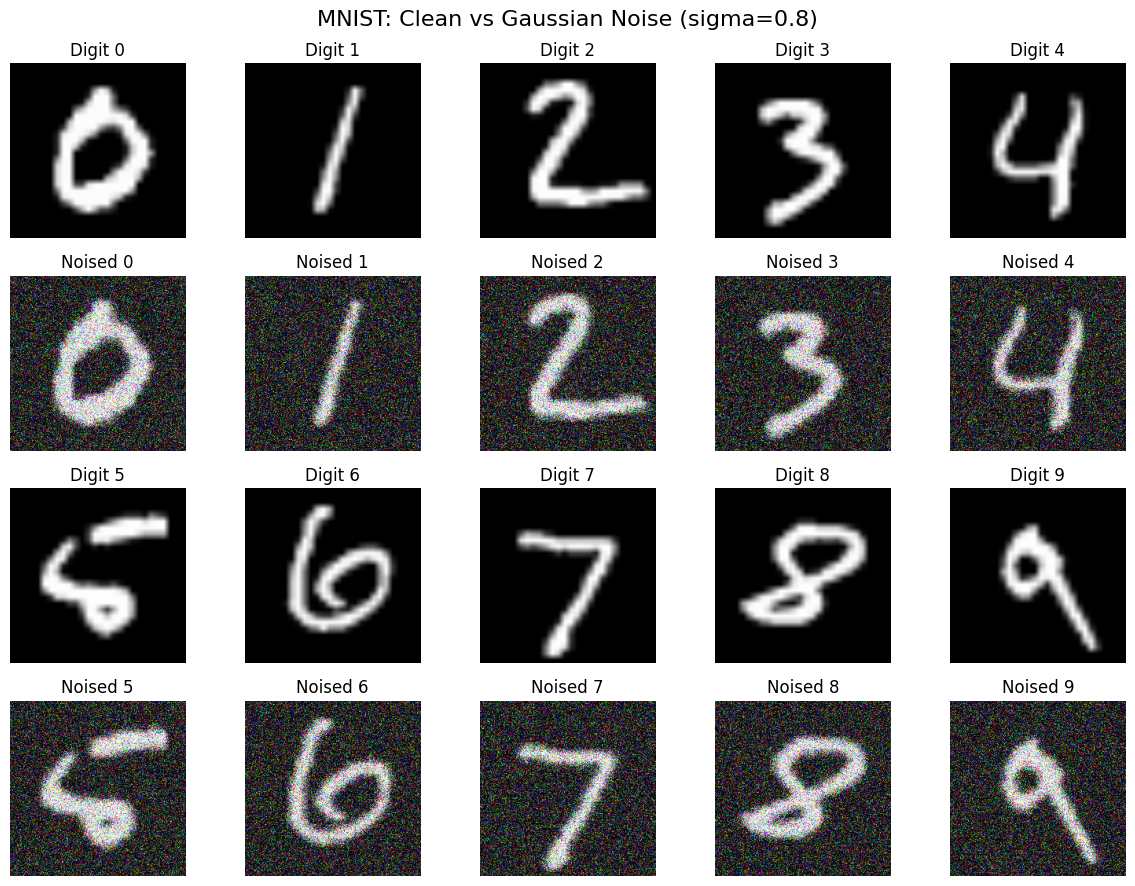

In [7]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Clean vs Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment.get_clean_tensor(
        class_id,
        to_device=False,
    )

    noised_tensor = perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        tensor_to_img(noised_tensor),
        title=f"Noised {class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG przykładów niezaszumionych oraz zaszumionych

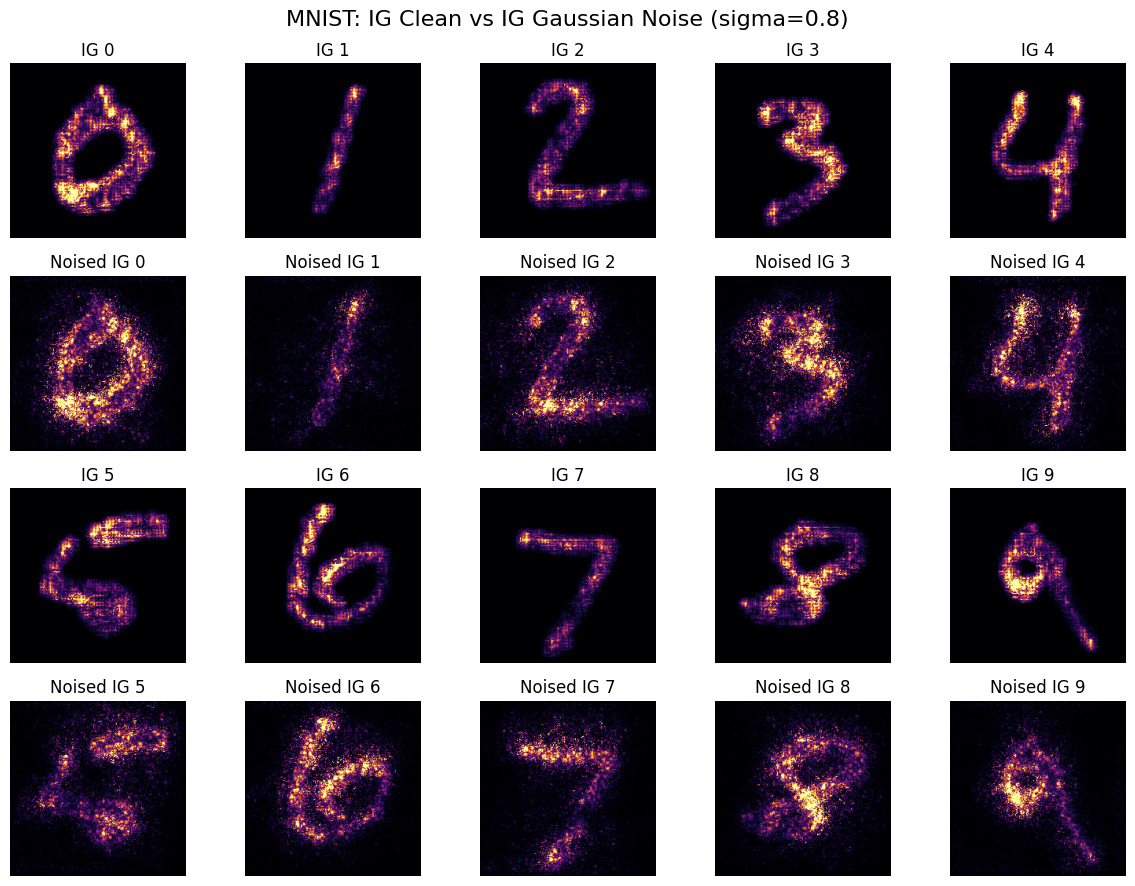

In [8]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: IG Clean vs IG Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment.get_clean_tensor(class_id)

    noised_tensor = ig_experiment.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    clean_attr = ig_experiment.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    noised_attr = ig_experiment.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_attr,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        noised_attr,
        title=f"Noised IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU

In [9]:
df_similarity = ig_experiment.run_similarity_metrics(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "TopK_IoU",
    ).round(3)
)

display(ig_experiment.summarize_similarity(df_similarity).round(3))

Processing gaussian=0.01
Processing gaussian=0.05
Processing gaussian=0.1
Processing gaussian=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.918,0.969,0.920,0.940,0.959,0.921,0.948,0.946,0.935,0.941
0.05,0.869,0.885,0.863,0.844,0.898,0.844,0.875,0.871,0.823,0.872
0.10,0.837,0.852,0.838,0.829,0.859,0.805,0.848,0.821,0.807,0.818
0.50,0.736,0.757,0.719,0.729,0.732,0.719,0.732,0.712,0.733,0.733


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.695,0.959,0.725,0.808,0.818,0.701,0.785,0.832,0.777,0.843
0.05,0.565,0.874,0.610,0.684,0.714,0.588,0.658,0.725,0.633,0.725
0.10,0.512,0.805,0.553,0.629,0.667,0.544,0.606,0.698,0.578,0.691
0.50,0.412,0.588,0.433,0.528,0.495,0.431,0.467,0.520,0.490,0.543


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.01,0.940,0.017,0.794,0.079
1,0.05,0.864,0.022,0.678,0.090
2,0.10,0.831,0.019,0.628,0.089
3,0.50,0.730,0.012,0.491,0.056


## Deletion AUC

In [10]:
df_deletion = ig_experiment.run_deletion_auc(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    ig_experiment.make_pivot(
        df_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(ig_experiment.summarize_deletion(df_deletion).round(3))

Processing gaussian=0.01
Processing gaussian=0.05
Processing gaussian=0.1
Processing gaussian=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.691,0.988,0.447,0.441,0.489,0.460,0.248,0.962,0.705,0.447
0.05,0.628,0.986,0.454,0.285,0.472,0.447,0.156,0.924,0.568,0.408
0.10,0.452,0.981,0.248,0.156,0.340,0.449,0.110,0.922,0.499,0.187
0.50,0.194,0.814,0.077,0.026,0.084,0.130,0.049,0.157,0.076,0.033


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.01,0.344,0.262,0.588,0.242,0.999,0.999,0
1,0.05,0.344,0.262,0.533,0.259,0.999,0.998,0
2,0.10,0.344,0.262,0.434,0.304,0.999,0.998,0
3,0.50,0.344,0.262,0.164,0.235,0.999,0.976,0


## Konfiguracja Occlusion

In [46]:
occ_explainer = OcclusionExplainer(
    model=model, device=device, config=config.OcclusionConfig()
)
occ_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=occ_explainer,
    perturbations=perturbations,
)

occ_classes = occ_experiment.selected_classes

all_occ_attrs = []
for class_id in occ_classes:
    clean_tensor = occ_experiment.get_clean_tensor(class_id)
    noised_tensor = occ_experiment.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=sigma,
    )

    clean_attr = occ_experiment.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["raw"]

    noised_attr = occ_experiment.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["raw"]

    all_occ_attrs.append(clean_attr)
    all_occ_attrs.append(noised_attr)

occ_vmin = min(attr.min() for attr in all_occ_attrs)
occ_vmax = max(attr.max() for attr in all_occ_attrs)


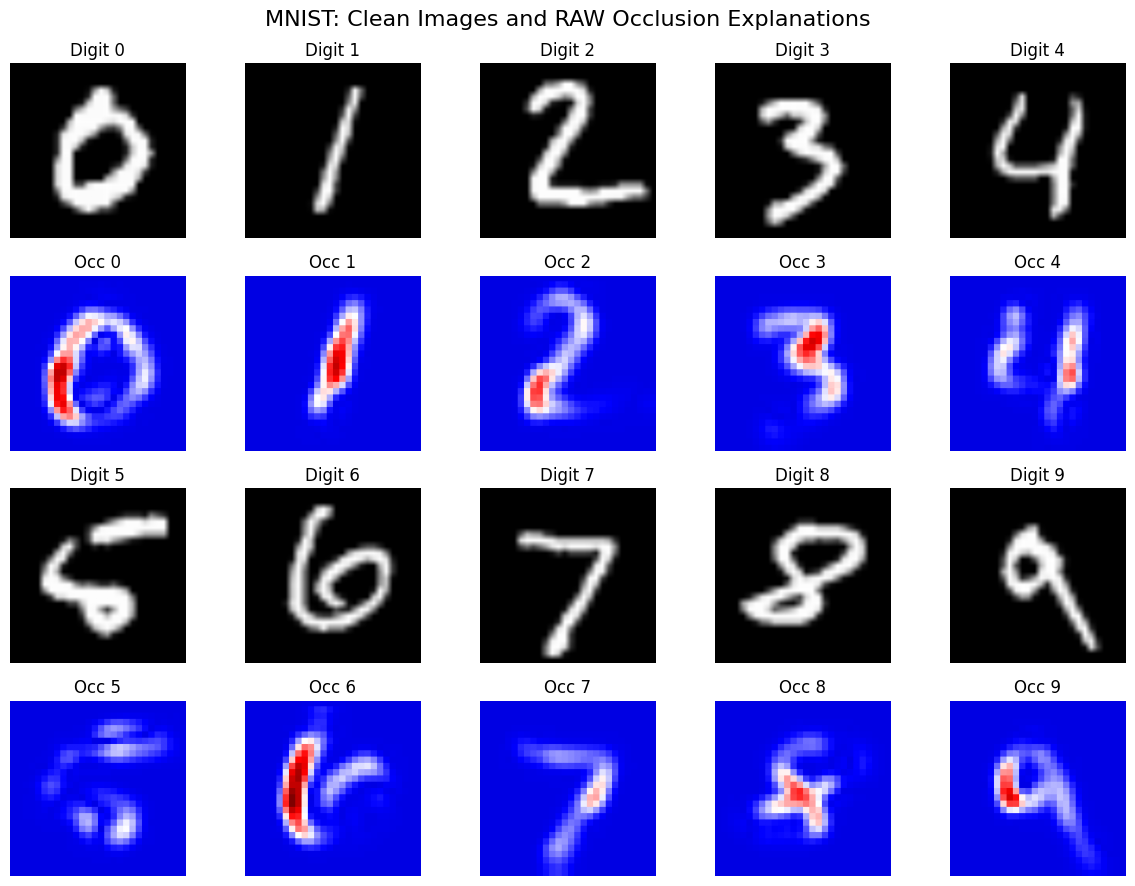

In [47]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "MNIST: Clean Images and RAW Occlusion Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment.get_clean_tensor(class_id)

    attr_occ = occ_experiment.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {occ_experiment.class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ,
        title=f"Occ {occ_experiment.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

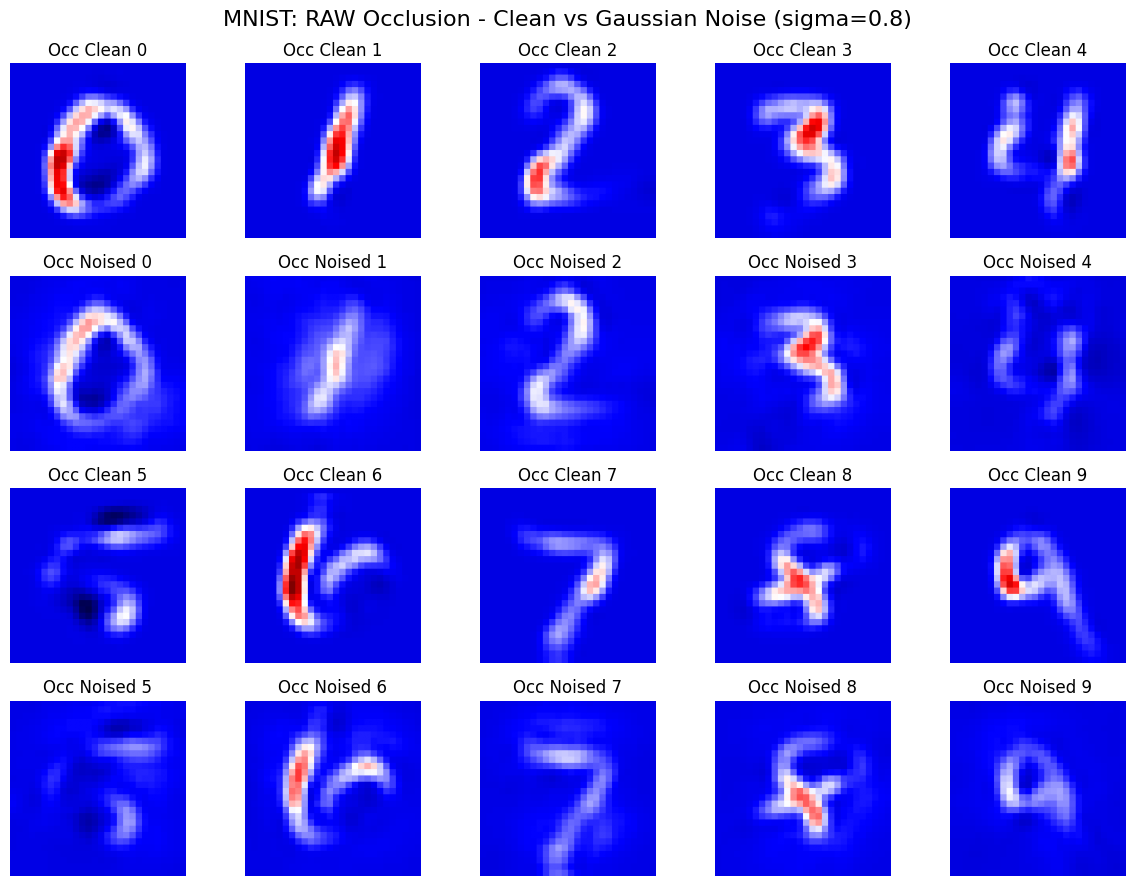

In [49]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: RAW Occlusion - Clean vs Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment.get_clean_tensor(class_id)

    noised_tensor = occ_experiment.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    attr_occ_clean = occ_experiment.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["raw"]

    attr_occ_noised = occ_experiment.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["raw"]

    plot_image(
        axes[block * 2, col],
        attr_occ_clean,
        title=f"Occ Clean {occ_experiment.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ_noised,
        title=f"Occ Noised {occ_experiment.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

In [32]:
df_occ_similarity = occ_experiment.run_similarity_metrics(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "TopK_IoU",
    ).round(3)
)

display(occ_experiment.summarize_similarity(df_occ_similarity).round(3))

Processing gaussian=0.01
Processing gaussian=0.05
Processing gaussian=0.1
Processing gaussian=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.05,1.000,1.000,1.000,1.000,0.999,1.000,1.000,1.000,1.000,1.000
0.10,0.999,0.999,0.999,1.000,0.997,0.999,0.999,0.999,0.999,0.998
0.50,0.987,0.971,0.975,0.982,0.930,0.967,0.983,0.952,0.959,0.964


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.997,0.998,0.998,0.997,0.997,0.996,0.997,0.999,0.996,0.996
0.05,0.991,0.984,0.978,0.994,0.978,0.984,0.975,0.975,0.975,0.987
0.10,0.978,0.953,0.962,0.981,0.948,0.965,0.966,0.969,0.962,0.962
0.50,0.861,0.860,0.858,0.909,0.815,0.844,0.877,0.831,0.807,0.850


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.01,1.000,0.000,0.997,0.001
1,0.05,1.000,0.000,0.982,0.007
2,0.10,0.999,0.001,0.965,0.010
3,0.50,0.967,0.017,0.851,0.030


In [28]:
df_occ_deletion = occ_experiment.run_deletion_auc(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(occ_experiment.summarize_deletion(df_occ_deletion).round(3))

Processing gaussian=0.01
Processing gaussian=0.05
Processing gaussian=0.1
Processing gaussian=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.149,0.992,0.097,0.121,0.128,0.491,0.078,0.132,0.144,0.071
0.05,0.146,0.992,0.096,0.118,0.125,0.514,0.074,0.129,0.139,0.070
0.10,0.148,0.993,0.107,0.106,0.119,0.363,0.076,0.120,0.137,0.070
0.50,0.191,0.990,0.080,0.073,0.116,0.359,0.200,0.135,0.151,0.040


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.01,0.228,0.281,0.240,0.291,0.999,0.999,0
1,0.05,0.228,0.281,0.240,0.294,0.999,0.998,0
2,0.10,0.228,0.281,0.224,0.283,0.999,0.998,0
3,0.50,0.228,0.281,0.234,0.280,0.999,0.968,0
